# 07 — Outlier Analysis

The last EDA notebook, and the one with a specific mandate: **separate true market events from data errors.**

These need opposite treatment:

- A **real event** — an earnings crash, a 2022-selloff day, a genuine spike — is *signal*. The jump-diffusion risk model exists precisely to capture these; deleting them would defeat the purpose.
- A **data error** — a bad tick, an unadjusted split, a feed glitch — is *noise* that should be fixed upstream or dropped.

The two look identical in a naive outlier count. Telling them apart takes judgment, so this notebook surfaces the extremes for inspection rather than auto-removing anything.

Sections:
1. **Extreme returns** — the largest daily moves, for event-vs-error triage
2. **Per-feature outliers** — which features have heavy tails
3. **Multivariate outliers in PC space** — rows that are jointly unusual
4. **Outlier clustering** — do the extremes form groups (a regime) or scatter (glitches)?
5. **Per-stock outlier rates** — a consistently extreme ticker may be a data-quality problem

In [1]:
from pathlib import Path
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.ensemble import IsolationForest
from sklearn.cluster import DBSCAN
from sklearn.covariance import EllipticEnvelope
from sklearn.neighbors import LocalOutlierFactor, NearestNeighbors

warnings.filterwarnings("ignore")
sns.set_theme(style="darkgrid", palette="colorblind")

In [2]:
# Ensure the project root is on the import path so `src` can be imported.
PROJECT_ROOT = Path.cwd().resolve()
for parent in (PROJECT_ROOT, *PROJECT_ROOT.parents):
    if (parent / 'src').is_dir():
        PROJECT_ROOT = parent
        break
else:
    raise RuntimeError('Run this notebook from inside the StockForecastRisk repository.')

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.forecast_engine.features.schema import FEATURE_NAMES
from src.forecast_engine.data.loader import PROCESSED_FEATURES_PATH, load_processed_features

data = load_processed_features()
data["date"] = pd.to_datetime(data["date"])
data = data.sort_values(["symbol", "date"]).reset_index(drop=True)

print(f'Loaded {len(data):,} rows for {data["symbol"].nunique():,} tickers')
print(f'Source: {PROCESSED_FEATURES_PATH}')
data.head()

Loaded 623,931 rows for 503 tickers
Source: D:\StockForecastRisk\data\processed\sp500_features.parquet


,date,symbol,security,gics_sector,gics_sub_industry,adj_close,close,high,low,open,...,month,quarter,ticker_id,sector_id,sector_avg_return_20d,relative_strength_sector_20d,days_to_next_earnings,future_return,future_direction,future_realized_vol
0,2021-07-12,A,Agilent Technologies,Health Care,Life Sciences Tools & Services,144.296738,149.509995,151.000000,149.169998,150.649994,...,7,3,0,5,NaN,NaN,NaN,-0.012993,0,0.004335
1,2021-07-13,A,Agilent Technologies,Health Care,Life Sciences Tools & Services,144.065094,149.270004,149.539993,148.190002,149.110001,...,7,3,0,5,NaN,NaN,NaN,0.000201,1,0.007756
2,2021-07-14,A,Agilent Technologies,Health Care,Life Sciences Tools & Services,143.447433,148.630005,149.869995,148.460007,149.860001,...,7,3,0,5,NaN,NaN,NaN,0.002151,1,0.007529
3,2021-07-15,A,Agilent Technologies,Health Care,Life Sciences Tools & Services,143.765884,148.960007,149.309998,147.839996,148.339996,...,7,3,0,5,NaN,NaN,NaN,0.008955,1,0.008487
4,2021-07-16,A,Agilent Technologies,Health Care,Life Sciences Tools & Services,143.736969,148.929993,149.820007,148.270004,149.330002,...,7,3,0,5,NaN,NaN,NaN,0.022442,1,0.009745


In [3]:
candidate = [c for c in FEATURE_NAMES if c in data.columns and data[c].notna().any()]
clean = data.dropna(subset=candidate).copy()
variances = clean[candidate].var()
features = [c for c in candidate if variances[c] > 0]
print(f"features: {len(features)}   complete-case rows: {len(clean):,}")

features: 42   complete-case rows: 506,798


### Note on short interest (2018+ coverage)

The short-interest features (`short_interest`, `short_interest_change`, `days_to_cover`,
`days_to_cover_change`) are the first non-price features. FINRA API coverage begins
~2018, so they are ~48% NaN over the full 2010–2026 panel. Their statistics in this
notebook therefore reflect the **2018+ subset only** — the `notna()` filtering above
already restricts each feature's computation to its available rows, so the numbers are
valid, but read short-interest rows as "2018 onward" rather than full-history. This is
the same partial-coverage caveat as the late-start credit spreads (see schema and
notebook 01). Any conclusion that hinges on short interest specifically should be
confirmed on an explicitly 2018-scoped slice.

In [4]:
clean["daily_return"] = clean.groupby("symbol")["adj_close"].pct_change()

extreme = clean.reindex(clean["daily_return"].abs().sort_values(ascending=False).index)
extreme_view = extreme[["date", "symbol", "gics_sector", "adj_close", "daily_return"]].head(20)

print("20 largest daily moves -- triage each as event (keep) or error (investigate):")
display(extreme_view.assign(daily_return=lambda d: (d["daily_return"] * 100).round(2)).reset_index(drop=True))

20 largest daily moves -- triage each as event (keep) or error (investigate):


,date,symbol,gics_sector,adj_close,daily_return
0,2025-08-26,ECHO,Communication Services,50.869999,70.25
1,2023-06-08,CVNA,Consumer Discretionary,4.846000,56.02
2,2024-04-11,GL,Financials,48.210213,-53.14
3,2025-06-16,ECHO,Communication Services,25.110001,49.11
4,2024-11-07,APP,Information Technology,246.529999,46.27
5,2023-01-12,CVNA,Consumer Discretionary,1.606000,46.00
6,2025-10-29,FISV,Financials,70.599998,-44.04
7,2022-12-07,CVNA,Consumer Discretionary,0.766000,-42.92
8,2024-07-26,DXCM,Health Care,64.000000,-40.66
9,2025-07-02,CNC,Health Care,33.779999,-40.37


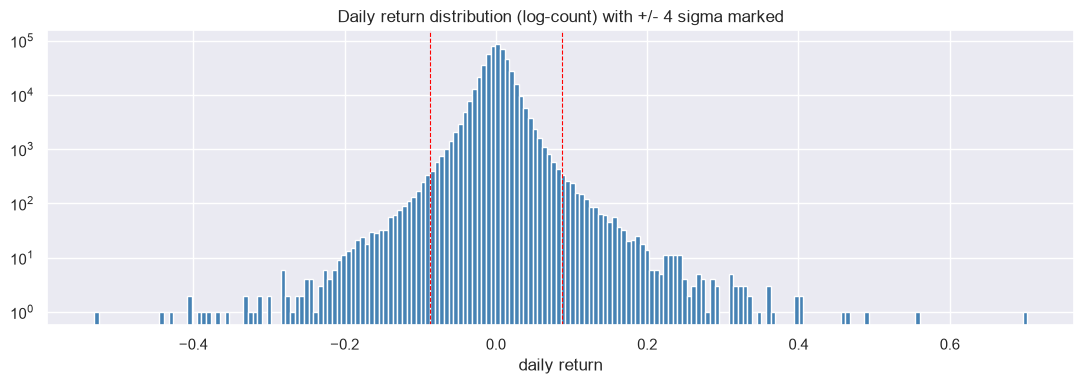

days beyond +/- 4 sigma: 3,439 (0.679% of observations)


In [31]:
# Distribution of daily returns with the extreme thresholds marked. A handful of
# points beyond +/- 4 sigma is normal for equities (fat tails); a wall of them,
# or points at implausible magnitudes (>50% in a day), suggests data problems.
returns = clean["daily_return"].dropna()
sigma = returns.std()

fig, ax = plt.subplots(figsize=(11, 4))
ax.hist(returns, bins=200, color="steelblue")
for k in (4, -4):
    ax.axvline(k * sigma, color="red", linestyle="--", linewidth=0.8)
ax.set_yscale("log")
ax.set_title("Daily return distribution (log-count) with +/- 4 sigma marked")
ax.set_xlabel("daily return")
plt.tight_layout()
plt.show()

beyond = int((returns.abs() > 4 * sigma).sum())
print(f"days beyond +/- 4 sigma: {beyond:,} ({beyond / len(returns):.3%} of observations)")

In [29]:
z_scores = (clean[features] - clean[features].mean()) / clean[features].std()
outlier_counts = (z_scores.abs() > 4).sum().sort_values(ascending=False)
outlier_counts = outlier_counts[outlier_counts > 0]

outlier_table = pd.DataFrame({
    "outliers_beyond_4z": outlier_counts,
    "pct_of_rows": (outlier_counts / len(clean) * 100).round(3),
})

print(f"{len(outlier_counts)} features have at least one |z| > 4 value:")
display(outlier_table)

33 features have at least one |z| > 4 value:


,outliers_beyond_4z,pct_of_rows
log_return_std_10,4373,0.863
realized_vol_10_annualized,4373,0.863
volume_to_sma_20,4168,0.822
bb_width_20,4073,0.804
realized_vol_20_annualized,4009,0.791
log_return_std_20,4009,0.791
volatility_lag_1d,4004,0.790
volatility_lag_5d,3987,0.787
macd_hist,3666,0.723
log_return_lag_5d,3437,0.678


In [30]:
# Modified z-score: median and MAD replace mean and std. The 0.6745 factor makes
# MAD a consistent estimator of the standard deviation under normality, so the 3.5
# cutoff is comparable in spirit to the plain-z cutoff above.
median = clean[features].median()
mad = (clean[features] - median).abs().median()
# A zero MAD (a near-constant feature) would divide by zero; guard it to NaN.
mad_safe = mad.replace(0, np.nan)
modified_z = 0.6745 * (clean[features] - median) / mad_safe

robust_counts = (modified_z.abs() > 3.5).sum()

comparison = pd.DataFrame({
    "plain_z_gt_4": (z_scores.abs() > 4).sum(),
    "mad_z_gt_3_5": robust_counts,
})
comparison["extra_caught_by_mad"] = comparison["mad_z_gt_3_5"] - comparison["plain_z_gt_4"]
comparison = comparison[comparison.sum(axis=1) > 0].sort_values("mad_z_gt_3_5", ascending=False)

print(f"total flags -- plain z>4: {int((z_scores.abs() > 4).sum().sum()):,}   "
      f"MAD z>3.5: {int(robust_counts.sum()):,}")
print("features where MAD catches far more had their std inflated by their own outliers:\n")
display(comparison.head(20))

# Collapse the per-feature flags to row level (a row is an outlier if extreme on
# at least one feature). Reused later so every technique shares one denominator.
row_z = (z_scores.abs() > 4).any(axis=1)
row_mad = (modified_z.abs() > 3.5).any(axis=1)


total flags -- plain z>4: 101,046   MAD z>3.5: 878,335
features where MAD catches far more had their std inflated by their own outliers:



,plain_z_gt_4,mad_z_gt_3_5,extra_caught_by_mad
obv,2196,74850,72654
obv_change_5,2655,65669,63014
macd_hist,3666,50193,46527
macd,3346,48427,45081
macd_signal,3287,47897,44610
atr_14,3258,39372,36114
sma_200,2416,38166,35750
sma_50,2412,37742,35330
ema_26,2437,37535,35098
sma_20,2442,37481,35039


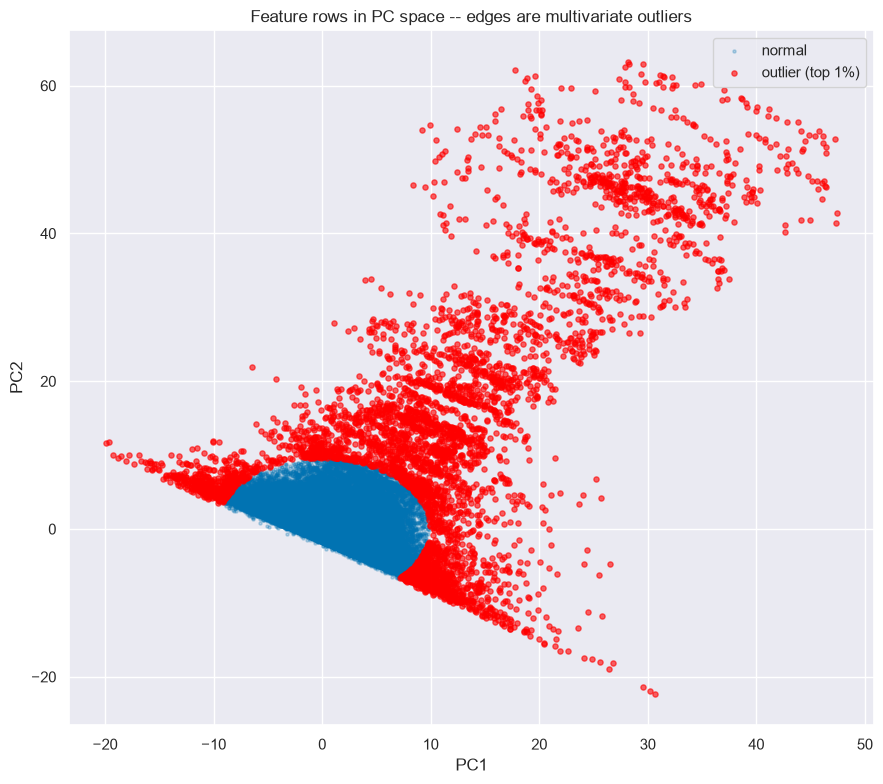

flagged 5,068 rows beyond the 99th percentile of PC distance


In [8]:
scaled = StandardScaler().fit_transform(clean[features])
projection = PCA(n_components=2, random_state=0).fit_transform(scaled)
clean["pc1"], clean["pc2"] = projection[:, 0], projection[:, 1]

# Distance from centre in standardised PC space; large = jointly unusual.
clean["pc_distance"] = np.sqrt(
    (clean["pc1"] / clean["pc1"].std()) ** 2 + (clean["pc2"] / clean["pc2"].std()) ** 2
)
threshold = clean["pc_distance"].quantile(0.99)
clean["pc_outlier"] = clean["pc_distance"] > threshold

fig, ax = plt.subplots(figsize=(9, 8))
normal = clean[~clean["pc_outlier"]]
flagged = clean[clean["pc_outlier"]]
ax.scatter(normal["pc1"], normal["pc2"], s=5, alpha=0.25, label="normal")
ax.scatter(flagged["pc1"], flagged["pc2"], s=14, color="red", alpha=0.6, label="outlier (top 1%)")
ax.set_title("Feature rows in PC space -- edges are multivariate outliers")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.legend()
plt.tight_layout()
plt.show()

print(f"flagged {int(clean['pc_outlier'].sum()):,} rows beyond the 99th percentile of PC distance")

In [9]:
# The most extreme multivariate rows, for inspection.
top_multivariate = clean.reindex(clean["pc_distance"].sort_values(ascending=False).index).head(15)
display(
    top_multivariate[["date", "symbol", "gics_sector", "daily_return", "pc_distance"]]
    .assign(daily_return=lambda d: (d["daily_return"] * 100).round(2))
    .reset_index(drop=True)
)

,date,symbol,gics_sector,daily_return,pc_distance
0,2024-10-02,NVR,Consumer Discretionary,-1.61,25.077942
1,2024-10-03,NVR,Consumer Discretionary,-0.99,25.020021
2,2024-10-04,NVR,Consumer Discretionary,-1.26,24.937136
3,2024-10-01,NVR,Consumer Discretionary,0.82,24.931524
4,2024-10-07,NVR,Consumer Discretionary,-0.98,24.907401
5,2024-10-23,NVR,Consumer Discretionary,-0.29,24.879195
6,2024-10-08,NVR,Consumer Discretionary,1.46,24.829961
7,2024-10-09,NVR,Consumer Discretionary,0.72,24.809831
8,2024-10-30,NVR,Consumer Discretionary,-0.63,24.766293
9,2024-09-30,NVR,Consumer Discretionary,0.79,24.766028


In [10]:
CONTAMINATION = 0.01  # expected outlier fraction; matches the PC-distance 99th pct

# Fit on the full standardised feature space, not the 2-D projection.
isolation_forest = IsolationForest(
    n_estimators=200,
    contamination=CONTAMINATION,
    random_state=0,
    n_jobs=-1,
)
clean["iso_outlier"] = isolation_forest.fit_predict(scaled) == -1
# score_samples: higher (less negative) = more normal; negate so higher = more anomalous.
clean["iso_anomaly"] = -isolation_forest.score_samples(scaled)

print(f"Isolation Forest flagged {int(clean['iso_outlier'].sum()):,} rows "
      f"(contamination = {CONTAMINATION:.0%})")

Isolation Forest flagged 5,068 rows (contamination = 1%)


,rows
Flagged by both,3674
PC-distance only,1394
Isolation Forest only,1394


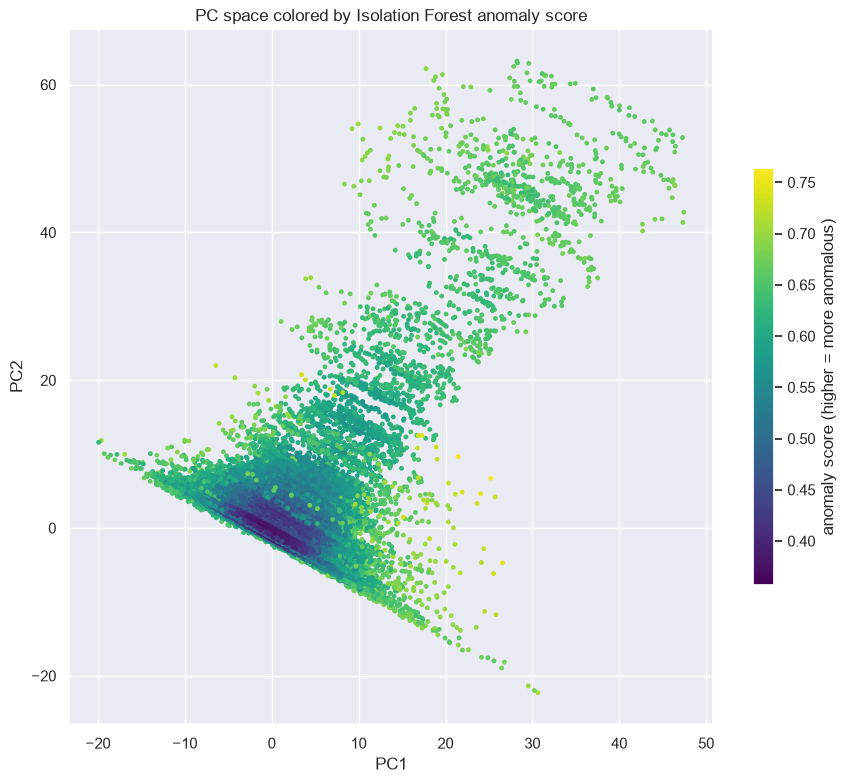

In [11]:
# Agreement between the two detectors. High overlap = robust anomalies; the
# method-specific rows show what each approach sees that the other does not.
both = int((clean["pc_outlier"] & clean["iso_outlier"]).sum())
only_pc = int((clean["pc_outlier"] & ~clean["iso_outlier"]).sum())
only_iso = int((~clean["pc_outlier"] & clean["iso_outlier"]).sum())

agreement = pd.DataFrame(
    {"rows": [both, only_pc, only_iso]},
    index=["Flagged by both", "PC-distance only", "Isolation Forest only"],
)
display(agreement)

fig, ax = plt.subplots(figsize=(9, 8))
scatter = ax.scatter(clean["pc1"], clean["pc2"], c=clean["iso_anomaly"], s=6, cmap="viridis")
ax.set_title("PC space colored by Isolation Forest anomaly score")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
plt.colorbar(scatter, ax=ax, label="anomaly score (higher = more anomalous)", shrink=0.6)
plt.tight_layout()
plt.show()

In [12]:
# The rows Isolation Forest considers most anomalous, with whether PC-distance
# agreed -- the triage shortlist.
top_iso = clean.reindex(clean["iso_anomaly"].sort_values(ascending=False).index).head(15)
display(
    top_iso[["date", "symbol", "gics_sector", "daily_return", "iso_anomaly", "pc_outlier"]]
    .assign(daily_return=lambda d: (d["daily_return"] * 100).round(2))
    .reset_index(drop=True)
)

,date,symbol,gics_sector,daily_return,iso_anomaly,pc_outlier
0,2026-06-26,SNDK,Information Technology,-10.46,0.763576,True
1,2026-07-01,SNDK,Information Technology,-10.62,0.754762,True
2,2026-06-22,SNDK,Information Technology,4.07,0.746333,True
3,2026-05-11,SNDK,Information Technology,-0.95,0.743050,True
4,2026-06-26,MU,Information Technology,-6.69,0.740738,True
5,2026-07-02,SNDK,Information Technology,-14.13,0.738259,True
6,2026-06-17,SNDK,Information Technology,-1.64,0.735472,True
7,2026-06-29,SNDK,Information Technology,-1.93,0.734175,True
8,2026-07-08,SNDK,Information Technology,6.77,0.734024,True
9,2026-06-16,SNDK,Information Technology,-5.52,0.733092,True


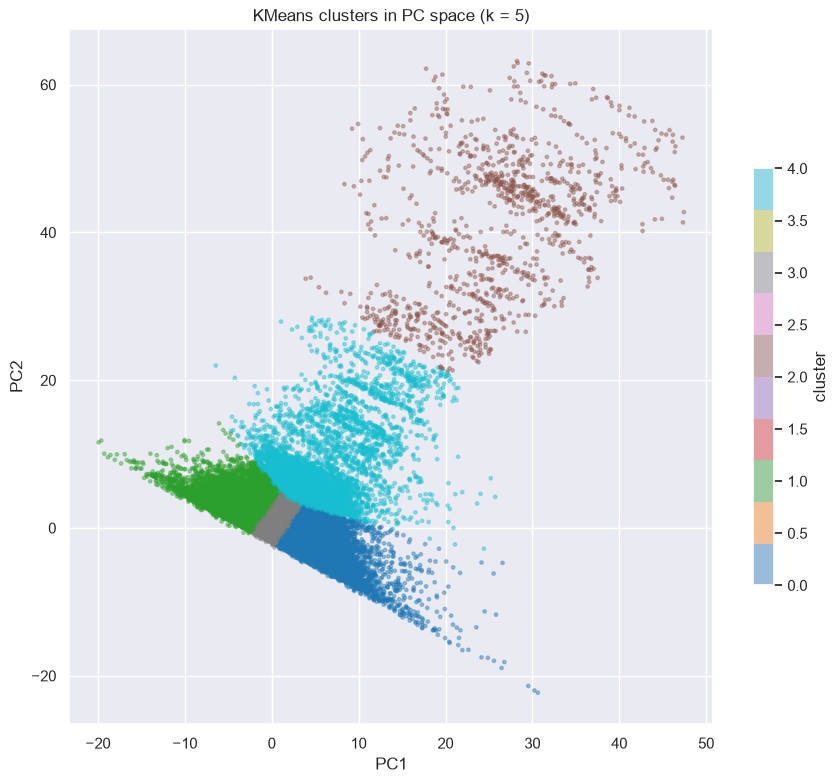

,rows,outlier_rate,mean_return
cluster,,,
0,147637,0.0081,0.0006
1,144552,0.0046,0.0010
2,1085,1.0000,0.0005
3,206160,0.0000,0.0005
4,7364,0.2892,0.0007


In [13]:
N_CLUSTERS = 5
clean["cluster"] = KMeans(n_clusters=N_CLUSTERS, random_state=0, n_init=10).fit_predict(projection)

fig, ax = plt.subplots(figsize=(9, 8))
scatter = ax.scatter(clean["pc1"], clean["pc2"], c=clean["cluster"], s=6, alpha=0.4, cmap="tab10")
ax.set_title(f"KMeans clusters in PC space (k = {N_CLUSTERS})")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
plt.colorbar(scatter, ax=ax, label="cluster", shrink=0.6)
plt.tight_layout()
plt.show()

# Outlier concentration by cluster: a cluster that is mostly outliers is a
# candidate 'stress regime' worth naming rather than deleting.
cluster_profile = clean.groupby("cluster").agg(
    rows=("pc_outlier", "size"),
    outlier_rate=("pc_outlier", "mean"),
    mean_return=("daily_return", "mean"),
)
display(cluster_profile.round(4))

In [14]:
per_stock = clean.groupby("symbol").agg(
    rows=("pc_outlier", "size"),
    outlier_days=("pc_outlier", "sum"),
    outlier_rate=("pc_outlier", "mean"),
    max_abs_return=("daily_return", lambda s: s.abs().max()),
).sort_values("outlier_rate", ascending=False)

print("Tickers with the highest outlier rates (inspect the top few for data issues):")
display(
    per_stock.head(15)
    .assign(
        outlier_rate=lambda d: (d["outlier_rate"] * 100).round(2),
        max_abs_return=lambda d: (d["max_abs_return"] * 100).round(2),
    )
)

Tickers with the highest outlier rates (inspect the top few for data issues):


,rows,outlier_days,outlier_rate,max_abs_return
symbol,,,,
NVR,1055,1055,100.00,11.24
AZO,1055,1055,100.00,9.46
SNDK,152,90,59.21,27.56
FICO,1055,475,45.02,31.10
MTD,1055,308,29.19,17.04
CVNA,1055,154,14.60,56.02
FIX,1055,122,11.56,25.71
SMCI,1055,106,10.05,35.94
COIN,1055,98,9.29,31.11


In [15]:
ROLLING_WINDOW = 63   # ~one trading quarter
ROLLING_THRESHOLD = 3.0


def rolling_zscore(group):
    returns = group["daily_return"]
    # shift(1): the window uses only prior days, never the current one.
    past_mean = returns.shift(1).rolling(ROLLING_WINDOW, min_periods=20).mean()
    past_std = returns.shift(1).rolling(ROLLING_WINDOW, min_periods=20).std()
    return (returns - past_mean) / past_std


clean["rolling_z"] = clean.groupby("symbol", group_keys=False).apply(rolling_zscore)
clean["rolling_outlier"] = clean["rolling_z"].abs() > ROLLING_THRESHOLD

# Global z-score on the same daily return, for contrast.
global_mean, global_std = clean["daily_return"].mean(), clean["daily_return"].std()
clean["global_return_z"] = (clean["daily_return"] - global_mean) / global_std
clean["global_return_outlier"] = clean["global_return_z"].abs() > ROLLING_THRESHOLD

rolling_only = int((clean["rolling_outlier"] & ~clean["global_return_outlier"]).sum())
print(f"rolling-z outliers (|z|>{ROLLING_THRESHOLD:.0f} vs recent history): {int(clean['rolling_outlier'].sum()):,}")
print(f"global-z outliers  (|z|>{ROLLING_THRESHOLD:.0f} vs whole dataset):  {int(clean['global_return_outlier'].sum()):,}")
print(f"flagged by rolling but NOT global: {rolling_only:,} "
      f"-- shocks relative to a calm period that global scoring misses")

rolling-z outliers (|z|>3 vs recent history): 7,745
global-z outliers  (|z|>3 vs whole dataset):  7,872
flagged by rolling but NOT global: 3,770 -- shocks relative to a calm period that global scoring misses


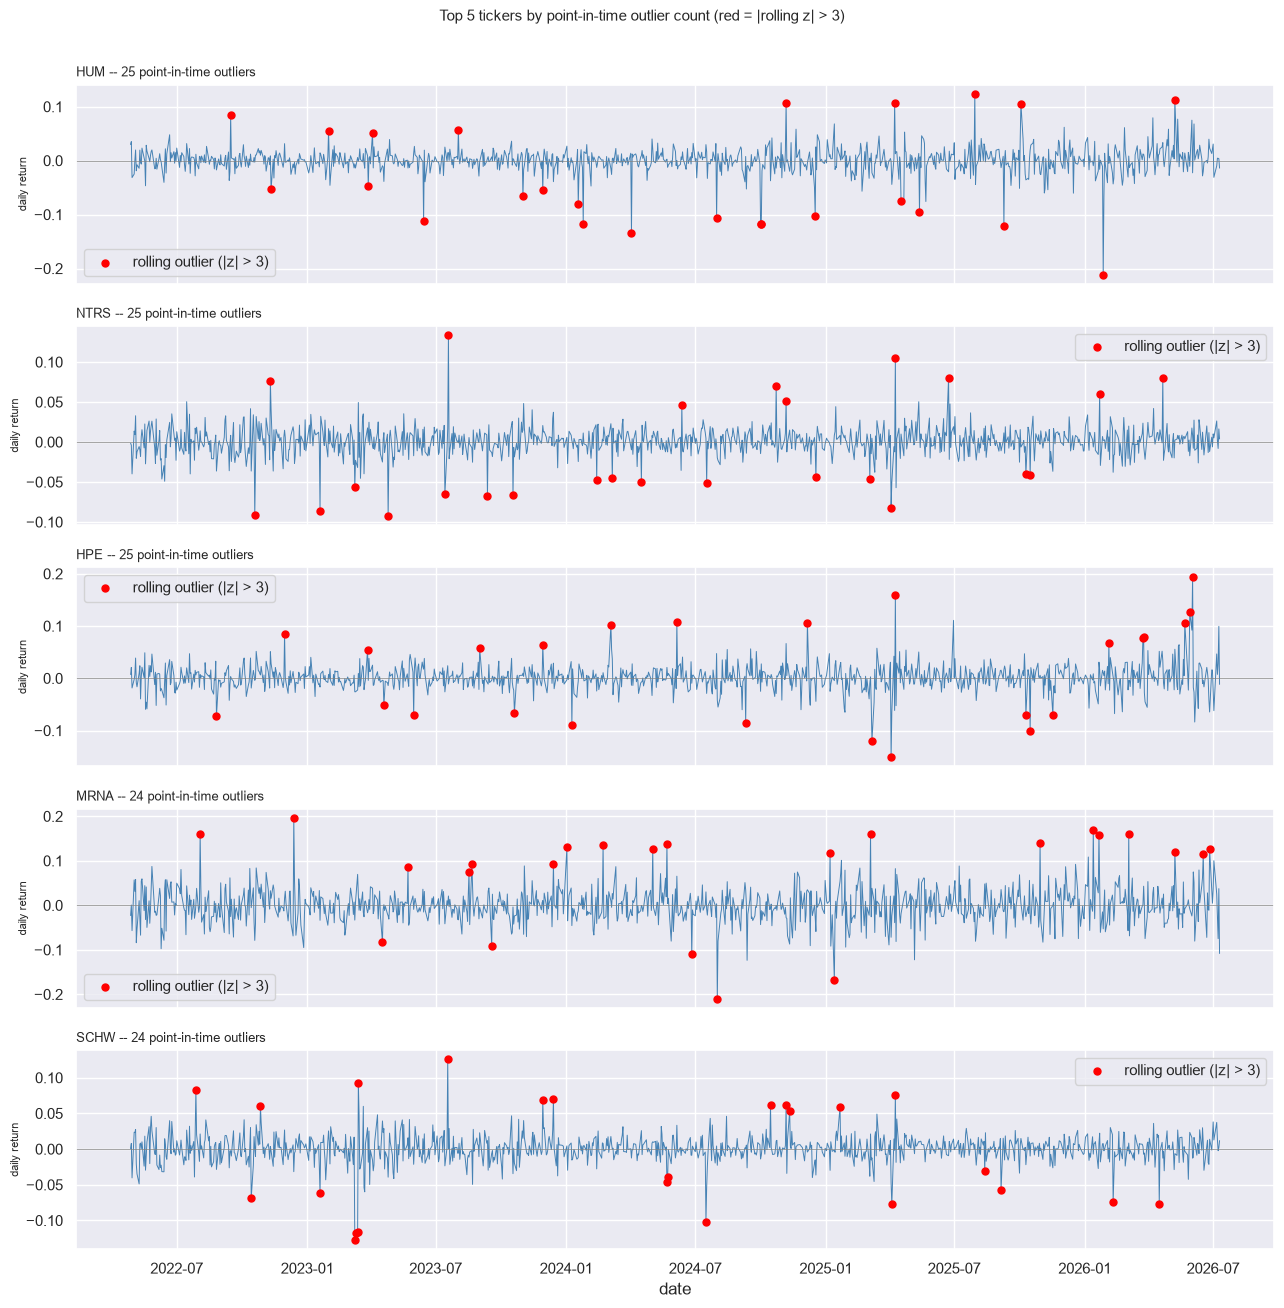

In [27]:
# The five tickers with the most point-in-time outliers, each with its returns and
# flagged days. Reading them together shows the flags landing where a move breaks
# from that stock's local regime -- not simply where the move is largest.
TOP_N = 5

top_symbols = (
    clean.groupby("symbol")["rolling_outlier"].sum().sort_values(ascending=False).head(TOP_N)
)

fig, axes = plt.subplots(TOP_N, 1, figsize=(13, 2.6 * TOP_N), sharex=True)
axes = np.atleast_1d(axes)

for ax, symbol in zip(axes, top_symbols.index):
    series = clean[clean["symbol"] == symbol].sort_values("date")
    flagged = series[series["rolling_outlier"]]
    ax.plot(series["date"], series["daily_return"], linewidth=0.7, color="steelblue")
    ax.scatter(flagged["date"], flagged["daily_return"], color="red", s=25, zorder=3,
           label=f"rolling outlier (|z| > {ROLLING_THRESHOLD:.0f})")
    ax.axhline(0, color="grey", linewidth=0.5)
    ax.set_title(f"{symbol} -- {int(top_symbols[symbol])} point-in-time outliers",
                 loc="left", fontsize=9)
    ax.set_ylabel("daily return", fontsize=8)
    ax.legend()

axes[-1].set_xlabel("date")
fig.suptitle(f"Top {TOP_N} tickers by point-in-time outlier count "
             f"(red = |rolling z| > {ROLLING_THRESHOLD:.0f})", fontsize=11, y=1.005)
plt.tight_layout()
plt.show()

In [ ]:
# --- Local Outlier Factor: full feature space -----------------------------
clean["lof_outlier"] = (
    LocalOutlierFactor(n_neighbors=20, contamination=CONTAMINATION).fit_predict(scaled) == -1
)

# --- Elliptic Envelope: Gaussian assumption, deliberately tested ----------
# support_fraction is set explicitly; the default can fail to converge on
# high-dimensional, heavy-tailed data.
clean["elliptic_outlier"] = (
    EllipticEnvelope(contamination=CONTAMINATION, support_fraction=0.9, random_state=0)
    .fit_predict(scaled) == -1
)

# --- DBSCAN: on the 2-D projection, eps from the k-distance elbow ---------
MIN_SAMPLES = 10
neighbour_distances, _ = NearestNeighbors(n_neighbors=MIN_SAMPLES).fit(projection).kneighbors(projection)
k_distance = np.sort(neighbour_distances[:, -1])
eps = float(np.percentile(k_distance, 95))
clean["dbscan_outlier"] = DBSCAN(eps=eps, min_samples=MIN_SAMPLES).fit_predict(projection) == -1

print(f"DBSCAN eps chosen from k-distance elbow: {eps:.3f}")
print(f"LOF flagged              : {int(clean['lof_outlier'].sum()):,}")
print(f"Elliptic Envelope flagged: {int(clean['elliptic_outlier'].sum()):,}")
print(f"DBSCAN flagged           : {int(clean['dbscan_outlier'].sum()):,}")

DBSCAN eps chosen from k-distance elbow: 0.064
LOF flagged              : 5,068
Elliptic Envelope flagged: 5,068
DBSCAN flagged           : 20,784


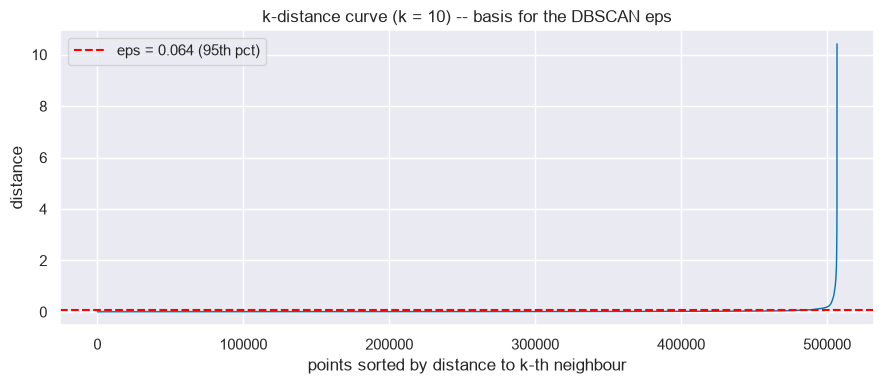

In [ ]:
# The k-distance curve DBSCAN's eps comes from. The 'elbow' -- where the curve
# turns sharply upward -- separates points in dense regions from isolated ones.
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(k_distance, linewidth=1)
ax.axhline(eps, color="red", linestyle="--", label=f"eps = {eps:.3f} (95th pct)")
ax.set_title(f"k-distance curve (k = {MIN_SAMPLES}) -- basis for the DBSCAN eps")
ax.set_xlabel("points sorted by distance to k-th neighbour")
ax.set_ylabel("distance")
ax.legend()
plt.tight_layout()
plt.show()

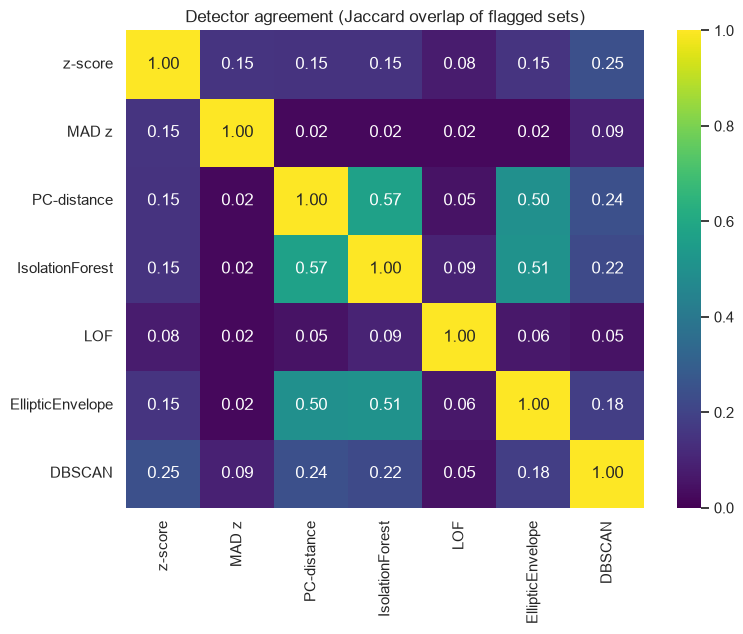

In [32]:
# Pairwise agreement between every detector: the fraction of rows on which two
# methods reach the same verdict. High agreement = the anomaly is robust to method
# choice; low = the methods are measuring genuinely different things.
flags = pd.DataFrame({
    "z-score": row_z,
    "MAD z": row_mad,
    "PC-distance": clean["pc_outlier"],
    "IsolationForest": clean["iso_outlier"],
    "LOF": clean["lof_outlier"],
    "EllipticEnvelope": clean["elliptic_outlier"],
    "DBSCAN": clean["dbscan_outlier"],
})

# Jaccard overlap on the FLAGGED sets is more informative than raw agreement,
# because with ~1% outliers two methods agree on ~98% of rows just by both
# saying 'normal' -- which tells you nothing.
methods = flags.columns
jaccard = pd.DataFrame(index=methods, columns=methods, dtype=float)
for a in methods:
    for b in methods:
        intersection = (flags[a] & flags[b]).sum()
        union = (flags[a] | flags[b]).sum()
        jaccard.loc[a, b] = intersection / union if union else np.nan

fig, ax = plt.subplots(figsize=(8, 6.5))
sns.heatmap(jaccard.astype(float), annot=True, fmt=".2f", cmap="viridis", vmin=0, vmax=1, ax=ax)
ax.set_title("Detector agreement (Jaccard overlap of flagged sets)")
plt.tight_layout()
plt.show()

In [33]:
# Row-level outlier flag from every technique. Per-feature methods collapse via
# .any(axis=1): a row is an outlier if extreme on at least one feature. The rest
# are already row-level, so all counts share one denominator.
total_rows = len(clean)

outlier_summary = pd.DataFrame(
    {
        "n_outliers": [
            int(row_z.sum()),
            int(row_mad.sum()),
            int(clean["pc_outlier"].sum()),
            int(clean["iso_outlier"].sum()),
            int(clean["lof_outlier"].sum()),
            int(clean["elliptic_outlier"].sum()),
            int(clean["dbscan_outlier"].sum()),
            int(clean["rolling_outlier"].sum()),
        ],
        "scope": [
            "univariate (global)",
            "univariate (global, robust)",
            "multivariate (2 PCs)",
            "multivariate (all features)",
            "multivariate (density)",
            "multivariate (Gaussian)",
            "multivariate (density, 2 PCs)",
            "time-series (per stock)",
        ],
    },
    index=[
        "z-score (|z|>4, any feature)",
        "MAD modified z (>3.5, any feature)",
        "PC-distance (99th pct)",
        "Isolation Forest (1%)",
        "Local Outlier Factor (1%)",
        "Elliptic Envelope (1%)",
        "DBSCAN (k-distance eps)",
        "Rolling z-score (|z|>3)",
    ],
)
outlier_summary["pct_of_rows"] = (outlier_summary["n_outliers"] / total_rows * 100).round(2)
outlier_summary = outlier_summary[["scope", "n_outliers", "pct_of_rows"]]

print(f"total rows: {total_rows:,}")
display(outlier_summary)

total rows: 506,798


,scope,n_outliers,pct_of_rows
"z-score (|z|>4, any feature)",univariate (global),34026,6.71
"MAD modified z (>3.5, any feature)","univariate (global, robust)",223970,44.19
PC-distance (99th pct),multivariate (2 PCs),5068,1.00
Isolation Forest (1%),multivariate (all features),5068,1.00
Local Outlier Factor (1%),multivariate (density),5068,1.00
Elliptic Envelope (1%),multivariate (Gaussian),5068,1.00
DBSCAN (k-distance eps),"multivariate (density, 2 PCs)",20784,4.10
Rolling z-score (|z|>3),time-series (per stock),7745,1.53


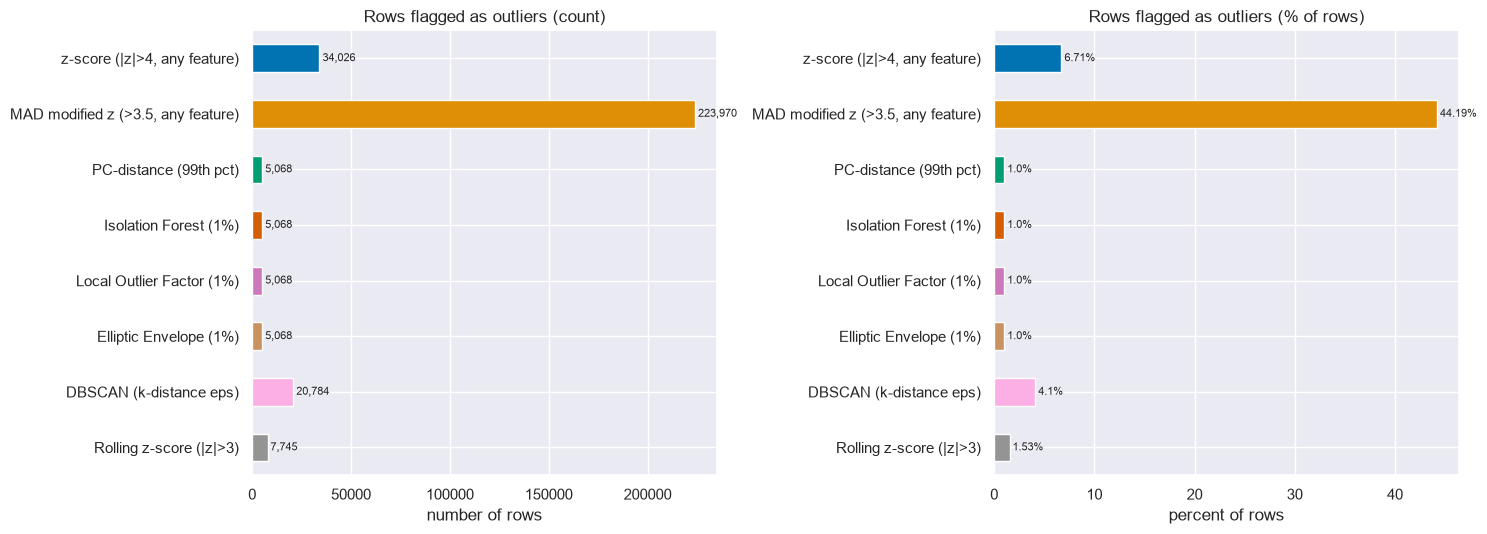

In [34]:
# Same numbers as bars: count on the left, percentage of rows on the right.
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
colors = sns.color_palette("colorblind", len(outlier_summary))

outlier_summary["n_outliers"].plot.barh(ax=axes[0], color=colors)
axes[0].set_title("Rows flagged as outliers (count)")
axes[0].set_xlabel("number of rows")
for i, value in enumerate(outlier_summary["n_outliers"]):
    axes[0].text(value, i, f" {value:,}", va="center", fontsize=8)

outlier_summary["pct_of_rows"].plot.barh(ax=axes[1], color=colors)
axes[1].set_title("Rows flagged as outliers (% of rows)")
axes[1].set_xlabel("percent of rows")
for i, value in enumerate(outlier_summary["pct_of_rows"]):
    axes[1].text(value, i, f" {value}%", va="center", fontsize=8)

axes[0].invert_yaxis()
axes[1].invert_yaxis()
plt.tight_layout()
plt.show()

## Triage notes

Record the judgment calls — this is the decision log for what stays and what gets fixed:

- **Extreme returns that are real events** (keep — these are what the jump model captures):
- **Extreme returns that look like errors** (investigate in ingestion):
- **Multivariate outliers worth understanding:**
- **Did outliers cluster** (regime) **or scatter** (glitches)?
- **Tickers with suspicious outlier rates** (possible data-quality issues):

**Principle:** do not blanket-remove outliers. Real tail events are the signal the risk half of the engine is built to model. Only remove what is demonstrably a data error; keep — and learn from — the rest.